In [1]:
import pandas as pd
import numpy as np

In [2]:
baseline = pd.read_csv("../data/processed/baseline_predictions.csv")
arima = pd.read_csv("../data/processed/arima_predictions.csv")
auto_arima = pd.read_csv("../data/processed/auto_arima_predictions.csv")
lstm = pd.read_csv("../data/processed/lstm_predictions.csv")
prophet = pd.read_csv("../data/processed/prophet_predictions.csv")

In [3]:
def evaluate_model(actual, predicted):

    mae = np.mean(np.abs(actual - predicted))
    
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return mae, rmse, mape

In [4]:
baseline_mae, baseline_rmse, baseline_mape = evaluate_model(
    baseline["Actual"],
    baseline["Prediction"]
)

In [5]:
arima_mae, arima_rmse, arima_mape = evaluate_model(
    arima["Actual"],
    arima["ARIMA_Prediction"]
)

In [6]:
auto_arima_mae, auto_arima_rmse, auto_arima_mape = evaluate_model(
    auto_arima["Actual"],
    auto_arima["Auto_ARIMA_Prediction"]
)

In [7]:
lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    lstm["Actual"],
    lstm["LSTM_Prediction"]
)

In [8]:
prophet_mae, prophet_rmse, prophet_mape = evaluate_model(
    prophet["Actual"],
    prophet["Prophet_Prediction"]
)

In [9]:
comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "ARIMA",
        "Auto ARIMA",
        "LSTM",
        "Prophet"
    ],

    "MAE": [
        baseline_mae,
        arima_mae,
        auto_arima_mae,
        lstm_mae,
        prophet_mae
    ],

    "RMSE": [
        baseline_rmse,
        arima_rmse,
        auto_arima_rmse,
        lstm_rmse,
        prophet_rmse
    ],

    "MAPE (%)": [
        baseline_mape,
        arima_mape,
        auto_arima_mape,
        lstm_mape,
        prophet_mape
    ]

})

comparison

,Model,MAE,RMSE,MAPE (%)
0,Baseline,97.816013,126.594562,2.645012
1,ARIMA,455.704969,508.351422,12.895959
2,Auto ARIMA,459.862899,510.432456,13.078723
3,LSTM,72.890165,96.049967,1.955704
4,Prophet,822.198280,1025.963451,24.853150


In [10]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("Best Model:")
print(best_model)

Best Model:
Model            LSTM
MAE         72.890165
RMSE        96.049967
MAPE (%)     1.955704
Name: 3, dtype: object


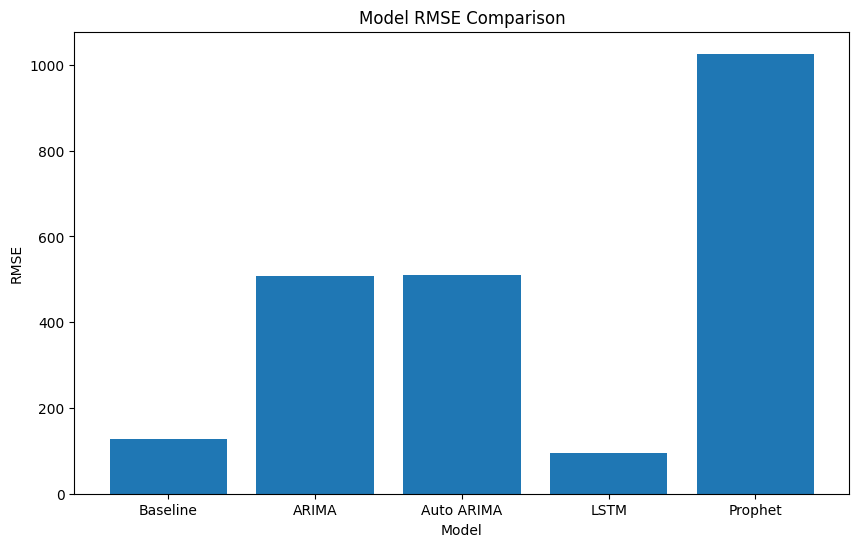

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("Model RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

In [13]:
comparison.to_csv("../data/processed/model_comparison.csv", index=False)